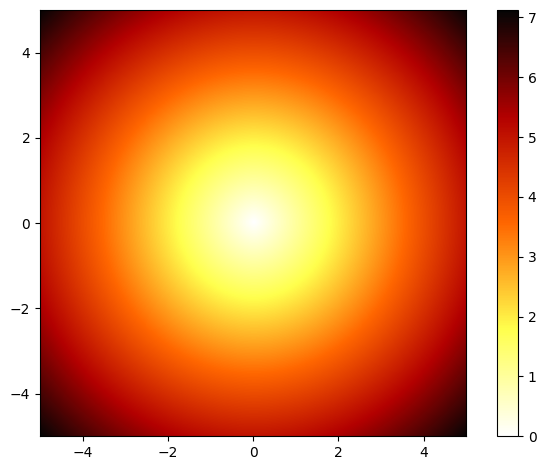

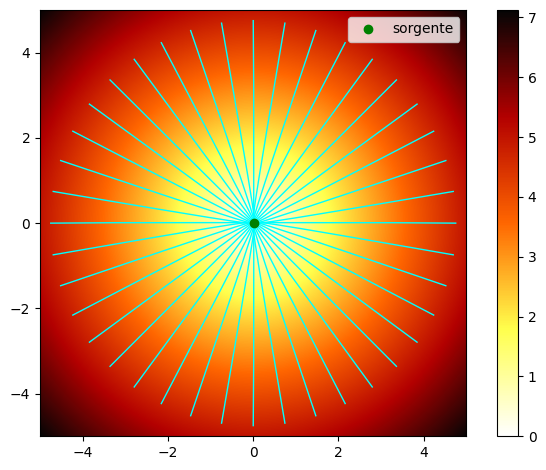

In [ ]:
# ==============================================================================
# ----------- VERSIONE FIM PARALLELIZZATA CON CUPY FASCIO IN SPAZIO LIBERO -----
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape)

wall_mask = np.isinf(F)
# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO ON CUPY
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0, iy0 = 250, 250
T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True


#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update(T, F, row, col):
    left  = cp.where(col - 1 >= 0,     T[row, cp.clip(col-1, 0, nCols-1)], cp.inf)
    right = cp.where(col + 1 < nCols,  T[row, cp.clip(col+1, 0, nCols-1)], cp.inf)
    down  = cp.where(row - 1 >= 0,     T[cp.clip(row-1, 0, nRows-1), col], cp.inf)
    up    = cp.where(row + 1 < nRows,  T[cp.clip(row+1, 0, nRows-1), col], cp.inf)

    Txmin = cp.minimum(left, right)
    Tymin = cp.minimum(down, up)

    a = cp.minimum(Txmin, Tymin)
    b = cp.maximum(Txmin, Tymin)

    f   = F[row, col]
    rhs = h / f

    cond   = (b - a) < rhs
    disc   = cp.maximum(2 * rhs**2 - (a - b)**2, 0)
    u_quad = (a + b + cp.sqrt(disc)) / 2
    u_lin  = a + rhs

    return cp.where(cond, u_quad, u_lin)


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    while cp.any(active):

        row, col = cp.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q

        converged_cond = cp.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]
        active[conv_row, conv_col] = False

        # ── propagazione ai vicini: vettorizzata con shift ────────────────────
        # invece del loop Python for r,c in [...], costruisco tutti e 4
        # i batch di vicini come array e li processo in un colpo solo

        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        # filtro: dentro griglia
        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        # filtro: non muri
        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # aggiorna solo se migliora T
        p2 = T[nb_row, nb_col]
        q2 = Godunov_update(T, F, nb_row, nb_col)

        improve = q2 < p2
        nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

        T[nb_row, nb_col]      = q2
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------
T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.QUAD + RK4)
# ==============================================================================

#------------------  UPLOAD SU GPU ----------------------------------------------

T_gpu    = cp.array(T_final)
wall_gpu = cp.array(wall_mask)
F_gpu    = cp.array(F)
x_gpu    = cp.array(x)
y_gpu    = cp.array(y)
nrows, ncols = T_gpu.shape

#------------------  UTILITY VETTORIALI ------------------------------------------

def clamp_index_quad_gpu(j, n):
    return cp.clip(j, 2, n - 3)

def is_wall_rc_gpu(row, col, wall_gpu):
    """row, col: array cupy interi. True se fuori griglia o muro."""
    nrows, ncols = wall_gpu.shape
    out_of_bounds = (row < 0) | (row >= nrows) | (col < 0) | (col >= ncols)
    row_c = cp.clip(row, 0, nrows - 1)
    col_c = cp.clip(col, 0, ncols - 1)
    return out_of_bounds | wall_gpu[row_c, col_c]

def is_wall_at_gpu(px, py, F_gpu, x_gpu, y_gpu):
    col = cp.clip(cp.searchsorted(x_gpu, px) - 1, 0, F_gpu.shape[1] - 1)
    row = cp.clip(cp.searchsorted(y_gpu, py) - 1, 0, F_gpu.shape[0] - 1)
    return cp.isinf(F_gpu[row, col])


#------------------  INTERPOLAZIONE QUADRATICA VETTORIALE (stesse regole 1D) -----

def quad_1d_or_fallback_gpu(f_m2, f_m1, f_0, f_1, f_2, s, h,
                             wall_m2, wall_m1, wall_1, wall_2, wall_0):
    """
    Tutti gli argomenti (tranne h) sono array cupy shape (n_rays,).
    Replica ESATTAMENTE la cascata if/elif della versione sequenziale,
    ma calcolando tutti i rami e selezionandoli con cp.where in ordine
    di priorità (dal più specifico al fallback finale).
    """
    eps_div = 1e-300  # solo per evitare warning su divisioni poi scartate da cp.where

    # --- ramo: entrambi muro ---
    val_1, der_1 = cp.zeros_like(f_0), cp.zeros_like(f_0)

    # --- ramo: f_0 muro, f_1 libero -> forward da f_1 ---
    der_2 = cp.where(~wall_2, (f_2 - f_1) / h, 0.0)
    val_2 = f_1

    # --- ramo: f_1 muro, f_0 libero -> backward da f_0 ---
    der_3 = cp.where(~wall_m1, (f_0 - f_m1) / h, 0.0)
    val_3 = f_0

    # --- rami con f_0, f_1 entrambi liberi ---

    # 4a-lin: wall_m1 True, wall_2 True -> lineare forward
    der_4a_lin = (f_1 - f_0) / h
    val_4a_lin = f_0 + s * h * der_4a_lin

    # 4a-quad: wall_m1 True, wall_2 False -> quadratica forward (f0,f1,f2)
    d1 = f_1 - f_0
    d2 = f_2 - 2*f_1 + f_0
    val_4a = f_0 + s*d1 + s*(s - 1)/2*d2
    der_4a = (d1 + (2*s - 1)/2*d2) / h

    # 4b: wall_m1 False, wall_m2 True -> lineare backward da f_m1
    der_4b = (f_0 - f_m1) / h
    val_4b = f_m1 + (s + 1) * h * der_4b

    # default: quadratica centrata standard
    val_def = f_0 + (f_1 - f_m1)/2*s + (f_1 - 2*f_0 + f_m1)/2*s**2
    der_def = ((f_1 - f_m1)/2 + (f_1 - 2*f_0 + f_m1)*s) / h

    # --- maschere mutuamente esclusive (stessa priorità del codice originale) ---
    m1  = wall_0 & wall_1
    m2  = wall_0 & ~wall_1
    m3  = wall_1 & ~wall_0
    free01 = ~wall_0 & ~wall_1
    m4a_lin = free01 & wall_m1 & wall_2
    m4a     = free01 & wall_m1 & ~wall_2
    m4b     = free01 & ~wall_m1 & wall_m2
    mdef    = free01 & ~wall_m1 & ~wall_m2

    val = cp.where(m1, val_1,
          cp.where(m2, val_2,
          cp.where(m3, val_3,
          cp.where(m4a_lin, val_4a_lin,
          cp.where(m4a, val_4a,
          cp.where(m4b, val_4b, val_def))))))

    der = cp.where(m1, der_1,
          cp.where(m2, der_2,
          cp.where(m3, der_3,
          cp.where(m4a_lin, der_4a_lin,
          cp.where(m4a, der_4a,
          cp.where(m4b, der_4b, der_def))))))

    return val, der


#------------------  GRADIENTE LOCALE VETTORIALE (batch di raggi) ---------------

def quad_local_grad_batch(px, py, T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy):
    """px, py: array cupy (n_rays,). Ritorna dT_dx, dT_dy come array (n_rays,)."""
    n_rays = px.shape[0]

    jx = cp.floor((px - x_gpu[0]) / dx).astype(cp.int32)
    jy = cp.floor((py - y_gpu[0]) / dy).astype(cp.int32)
    jx = clamp_index_quad_gpu(jx, ncols)
    jy = clamp_index_quad_gpu(jy, nrows)

    sx = (px - x_gpu[jx]) / dx
    sy = (py - y_gpu[jy]) / dy

    g_val = cp.empty((5, n_rays))
    g_dx  = cp.empty((5, n_rays))

    for k, ry in enumerate((-2, -1, 0, 1, 2)):
        row = jy + ry   # array (n_rays,)

        f_m2 = T_gpu[row, jx - 2]
        f_m1 = T_gpu[row, jx - 1]
        f_0  = T_gpu[row, jx]
        f_1  = T_gpu[row, jx + 1]
        f_2  = T_gpu[row, jx + 2]

        wall_m2 = is_wall_rc_gpu(row, jx - 2, wall_gpu)
        wall_m1 = is_wall_rc_gpu(row, jx - 1, wall_gpu)
        wall_0  = is_wall_rc_gpu(row, jx, wall_gpu)
        wall_1  = is_wall_rc_gpu(row, jx + 1, wall_gpu)
        wall_2  = is_wall_rc_gpu(row, jx + 2, wall_gpu)

        g_val[k], g_dx[k] = quad_1d_or_fallback_gpu(
            f_m2, f_m1, f_0, f_1, f_2, sx, dx,
            wall_m2, wall_m1, wall_1, wall_2, wall_0)

    wall_m2y = is_wall_rc_gpu(jy - 2, jx, wall_gpu) | is_wall_rc_gpu(jy - 2, jx + 1, wall_gpu)
    wall_m1y = is_wall_rc_gpu(jy - 1, jx, wall_gpu) | is_wall_rc_gpu(jy - 1, jx + 1, wall_gpu)
    wall_0y  = is_wall_rc_gpu(jy,     jx, wall_gpu) | is_wall_rc_gpu(jy,     jx + 1, wall_gpu)
    wall_1y  = is_wall_rc_gpu(jy + 1, jx, wall_gpu) | is_wall_rc_gpu(jy + 1, jx + 1, wall_gpu)
    wall_2y  = is_wall_rc_gpu(jy + 2, jx, wall_gpu) | is_wall_rc_gpu(jy + 2, jx + 1, wall_gpu)

    _, dT_dy = quad_1d_or_fallback_gpu(
        g_val[0], g_val[1], g_val[2], g_val[3], g_val[4], sy, dy,
        wall_m2y, wall_m1y, wall_1y, wall_2y, wall_0y)

    dT_dx, _ = quad_1d_or_fallback_gpu(
        g_dx[0], g_dx[1], g_dx[2], g_dx[3], g_dx[4], sy, dy,
        wall_m2y, wall_m1y, wall_1y, wall_2y, wall_0y)

    return dT_dx, dT_dy


def grad_at_local_batch(px, py, T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy):
    gx, gy = quad_local_grad_batch(px, py, T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy)
    invalid = ~(cp.isfinite(gx) & cp.isfinite(gy))
    gx = cp.where(invalid, 0.0, gx)
    gy = cp.where(invalid, 0.0, gy)

    norm = cp.sqrt(gx**2 + gy**2)
    too_small = norm < 1e-12
    scale = cp.where(too_small, 0.0, 1.0 / cp.where(too_small, 1.0, norm))
    return gx * scale, gy * scale


#------------------  RK4 VETTORIALE + STEP-HALVING ADATTIVO ---------------------

def trace_rays_rk4_quad_batch(start_pts, source_pt, T_gpu, wall_gpu, F_gpu,
                               x_gpu, y_gpu, dx, dy, ds, max_steps):

    n_rays = start_pts.shape[0]
    px = cp.array(start_pts[:, 0])
    py = cp.array(start_pts[:, 1])
    sx, sy = source_pt

    active = cp.ones(n_rays, dtype=bool)
    traj = [cp.stack([px, py], axis=1)]

    for step in range(max_steps):
        if not cp.any(active):
            break

        k1x, k1y = grad_at_local_batch(px, py, T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy)
        k1x, k1y = -k1x, -k1y

        k2x, k2y = grad_at_local_batch(px + 0.5*ds*k1x, py + 0.5*ds*k1y,
                                        T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy)
        k2x, k2y = -k2x, -k2y

        k3x, k3y = grad_at_local_batch(px + 0.5*ds*k2x, py + 0.5*ds*k2y,
                                        T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy)
        k3x, k3y = -k3x, -k3y

        k4x, k4y = grad_at_local_batch(px + ds*k3x, py + ds*k3y,
                                        T_gpu, wall_gpu, x_gpu, y_gpu, dx, dy)
        k4x, k4y = -k4x, -k4y

        dpx = (k1x + 2*k2x + 2*k3x + k4x) / 6.0
        dpy = (k1y + 2*k2y + 2*k3y + k4y) / 6.0

        speed = cp.sqrt(dpx**2 + dpy**2)
        stalled = speed < 1e-12

        # --- step-halving adattivo vettoriale: ogni raggio ha il proprio step_ds ---
        step_ds = cp.full(n_rays, ds)
        px_new = px + step_ds * dpx
        py_new = py + step_ds * dpy

        for _try in range(8):
            hit_wall = is_wall_at_gpu(px_new, py_new, F_gpu, x_gpu, y_gpu) & active
            if not cp.any(hit_wall):
                break
            step_ds = cp.where(hit_wall, step_ds * 0.5, step_ds)
            px_new = cp.where(hit_wall, px + step_ds * dpx, px_new)
            py_new = cp.where(hit_wall, py + step_ds * dpy, py_new)

        px_new = cp.where(active, px_new, px)
        py_new = cp.where(active, py_new, py)

        dist_to_source = cp.sqrt((px_new - sx)**2 + (py_new - sy)**2)
        reached = dist_to_source < ds

        disp = cp.sqrt((px_new - px)**2 + (py_new - py)**2)
        stuck = disp < 1e-8

        active = active & ~(reached | stalled | stuck)

        px, py = px_new, py_new
        traj.append(cp.stack([px, py], axis=1))

    traj_gpu = cp.stack(traj, axis=0)
    return cp.asnumpy(traj_gpu)


#------------------  LANCIO DEL FASCIO -------------------------------------------

n_rays = 40
R_exit = sidex * 0.95
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

start_pts = np.stack([R_exit*np.cos(angles), R_exit*np.sin(angles)], axis=1)
source_pt = (x[ix0], y[iy0])

ds = dx/2
max_steps = 10000

traj = trace_rays_rk4_quad_batch(start_pts, source_pt, T_gpu, wall_gpu, F_gpu,
                                  x_gpu, y_gpu, dx, dy, ds, max_steps)

rays_fan = [traj[:, i, :] for i in range(n_rays)]

#------------------  PLOT ---------------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)
for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)
ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()